# Dry Bean Model Training & Model Export

This notebook trains five supervised machine learning models using the preprocessed Dry Bean dataset.

Outputs Generated:

- logistic_regression.pkl
- decision_tree.pkl
- knn.pkl
- naive_bayes.pkl
- random_forest.pkl
- model_comparison.csv

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [6]:
import time

start = time.time()

# ==========================================================
# Create output folders
# ==========================================================

In [7]:
os.makedirs("model", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ==========================================================
# Load Dataset
# ==========================================================

In [8]:
print("=" * 70)
print("Loading Dry Bean Dataset...")
print("=" * 70)
filename="Dry_Bean_Dataset.xlsx"
df = pd.read_excel(filename)

print("\nDataset Loaded Successfully")

print("\nShape :", df.shape)

print("\nFirst Five Records")
print(df.head())

Loading Dry Bean Dataset...

Dataset Loaded Successfully

Shape : (13611, 17)

First Five Records
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactne

In [9]:

# ==========================================================
# Dataset Information
# ==========================================================

print("\n" + "=" * 70)
print("Dataset Information")
print("=" * 70)

print(df.info())

print("\nSummary Statistics")

print(df.describe().T)

# ==========================================================
# Missing Values
# ==========================================================

print("\n" + "=" * 70)
print("Missing Values")
print("=" * 70)

missing = df.isnull().sum()

print(missing)

if missing.sum() == 0:
    print("\nNo Missing Values Found")

# ==========================================================
# Duplicate Records
# ==========================================================

print("\n" + "=" * 70)
print("Duplicate Records")
print("=" * 70)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates Removed")

print("\nDataset Shape :", df.shape)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  obje

In [10]:
# ==========================================================
# Target Distribution
# ==========================================================

print("\n" + "=" * 70)
print("Target Classes")
print("=" * 70)

print(df["Class"].value_counts())

# ==========================================================
# Label Encoding
# ==========================================================

print("\nEncoding Target Variable...")

encoder = LabelEncoder()

df["Class"] = encoder.fit_transform(df["Class"])

print("Classes")

for i, c in enumerate(encoder.classes_):
    print(f"{i} --> {c}")

joblib.dump(
    encoder,
    "model/label_encoder.pkl"
)

print("\nLabel Encoder Saved")



Target Classes
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Encoding Target Variable...
Classes
0 --> BARBUNYA
1 --> BOMBAY
2 --> CALI
3 --> DERMASON
4 --> HOROZ
5 --> SEKER
6 --> SIRA

Label Encoder Saved


In [11]:
# ==========================================================
# Feature Matrix
# ==========================================================

X = df.drop("Class", axis=1)

y = df["Class"]

print("\nFeature Shape :", X.shape)

print("Target Shape :", y.shape)


Feature Shape : (13543, 16)
Target Shape : (13543,)


In [12]:
# ==========================================================
# Train Test Split
# ==========================================================

print("\nSplitting Dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)


Splitting Dataset...
Training Samples : (10834, 16)
Testing Samples : (2709, 16)


In [13]:
# ==========================================================
# Feature Scaling
# ==========================================================

print("\nScaling Features...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("Scaler Saved")



Scaling Features...
Scaler Saved


In [14]:
# ==========================================================
# Save Train/Test Data
# ==========================================================

train_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

train_df["Class"] = y_train.reset_index(drop=True)

test_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

test_df["Class"] = y_test.reset_index(drop=True)

train_df.to_csv(
    "output/train_processed.csv",
    index=False
)

test_df.to_csv(
    "output/test_data.csv",
    index=False
)

print("\nProcessed datasets saved.")

print("train_processed.csv")

print("test_data.csv")


Processed datasets saved.
train_processed.csv
test_data.csv


In [15]:
# ==========================================================
# Model Training
# ==========================================================

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestClassifier

print("\n")
print("="*70)
print("MODEL TRAINING")
print("="*70)

trained_models = {}

# ==========================================================
# Logistic Regression
# ==========================================================

print("\nTraining Logistic Regression...")

lr_parameters = {
    "C":[0.1,1,10]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(
    X_train_scaled,
    y_train
)

logistic_model = lr_grid.best_estimator_

trained_models["Logistic Regression"] = logistic_model

print("Best Parameters :", lr_grid.best_params_)

# ==========================================================
# Decision Tree
# ==========================================================

print("\nTraining Decision Tree...")

dt_parameters = {

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10]

}

dt_grid = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    dt_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

dt_grid.fit(

    X_train_scaled,

    y_train

)

decision_tree_model = dt_grid.best_estimator_

trained_models["Decision Tree"] = decision_tree_model

print("Best Parameters :",dt_grid.best_params_)

# ==========================================================
# KNN
# ==========================================================

print("\nTraining KNN...")

knn_parameters = {

    "n_neighbors":[3,5,7,9],

    "weights":["uniform","distance"]

}

knn_grid = GridSearchCV(

    KNeighborsClassifier(),

    knn_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

knn_grid.fit(

    X_train_scaled,

    y_train

)

knn_model = knn_grid.best_estimator_

trained_models["KNN"] = knn_model

print("Best Parameters :",knn_grid.best_params_)

# ==========================================================
# Gaussian Naive Bayes
# ==========================================================

print("\nTraining Gaussian Naive Bayes...")

naive_bayes_model = GaussianNB()

naive_bayes_model.fit(

    X_train_scaled,

    y_train

)

trained_models["Naive Bayes"] = naive_bayes_model

print("Training Completed")

# ==========================================================
# Random Forest
# ==========================================================

print("\nTraining Random Forest...")

rf_parameters = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(

        random_state=42

    ),

    rf_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(

    X_train_scaled,

    y_train

)

random_forest_model = rf_grid.best_estimator_

trained_models["Random Forest"] = random_forest_model

print("Best Parameters :",rf_grid.best_params_)

import os

os.makedirs("model", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ==========================================================
# Save Models
# ==========================================================

print("\nSaving Models...")

joblib.dump(logistic_model, "model/logistic_regression.pkl")

joblib.dump(decision_tree_model,"model/decision_tree.pkl")

joblib.dump(knn_model,"model/knn.pkl")

joblib.dump(naive_bayes_model,"model/naive_bayes.pkl")

joblib.dump(random_forest_model,"model/random_forest.pkl")

print("All Models Saved Successfully")






MODEL TRAINING

Training Logistic Regression...
Best Parameters : {'C': 10}

Training Decision Tree...
Best Parameters : {'max_depth': 10, 'min_samples_split': 10}

Training KNN...
Best Parameters : {'n_neighbors': 7, 'weights': 'distance'}

Training Gaussian Naive Bayes...
Training Completed

Training Random Forest...
Best Parameters : {'max_depth': 20, 'n_estimators': 100}

Saving Models...
All Models Saved Successfully




MODEL EVALUATION

Logistic Regression

Classification Report

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.91      0.94      0.92       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



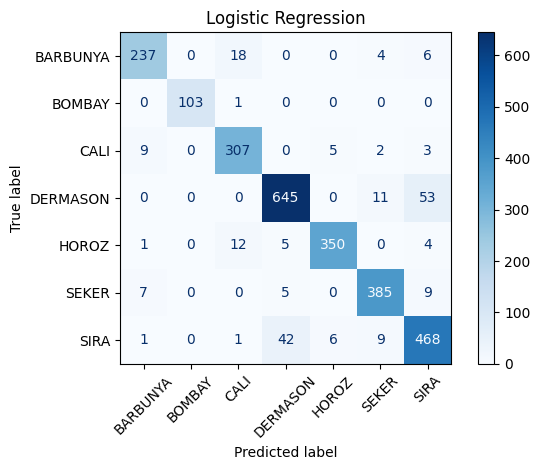


Decision Tree

Classification Report

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.93      0.91       326
    DERMASON       0.90      0.90      0.90       709
       HOROZ       0.96      0.92      0.94       372
       SEKER       0.92      0.95      0.93       406
        SIRA       0.84      0.83      0.84       527

    accuracy                           0.90      2709
   macro avg       0.92      0.92      0.92      2709
weighted avg       0.90      0.90      0.90      2709



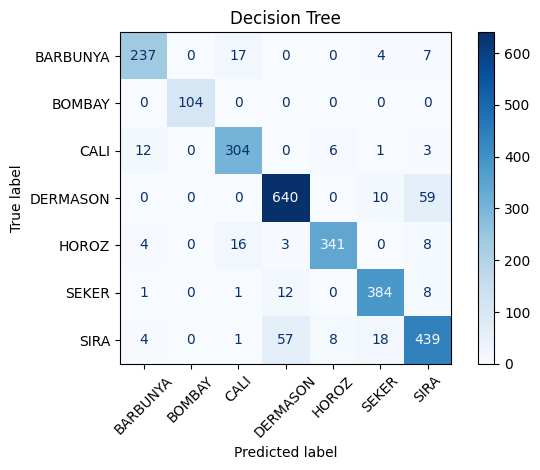


KNN

Classification Report

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.87      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.89      0.94      0.92       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.91      2709
   macro avg       0.93      0.92      0.93      2709
weighted avg       0.91      0.91      0.91      2709



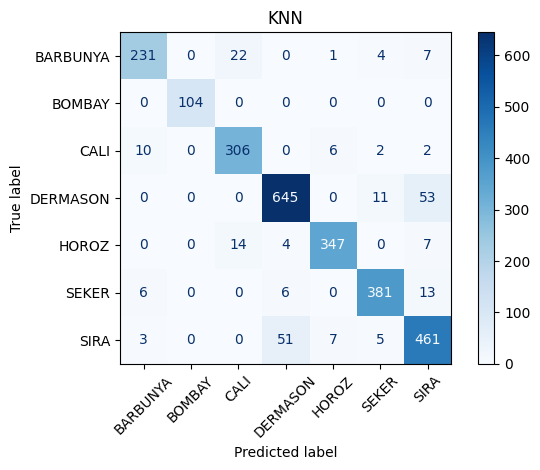


Naive Bayes

Classification Report

              precision    recall  f1-score   support

    BARBUNYA       0.87      0.80      0.83       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.86      0.92      0.89       326
    DERMASON       0.94      0.86      0.90       709
       HOROZ       0.95      0.95      0.95       372
       SEKER       0.92      0.94      0.93       406
        SIRA       0.81      0.90      0.85       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



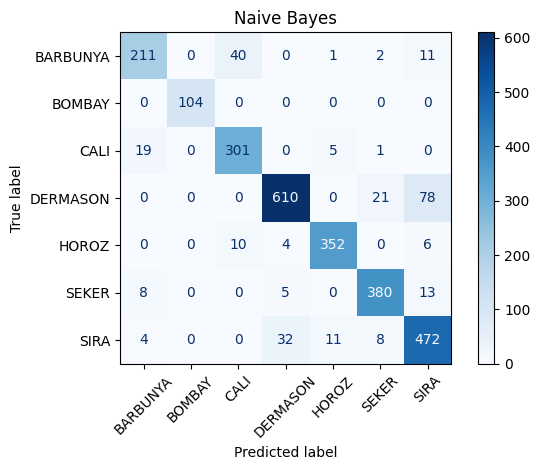


Random Forest

Classification Report

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.93      0.92       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



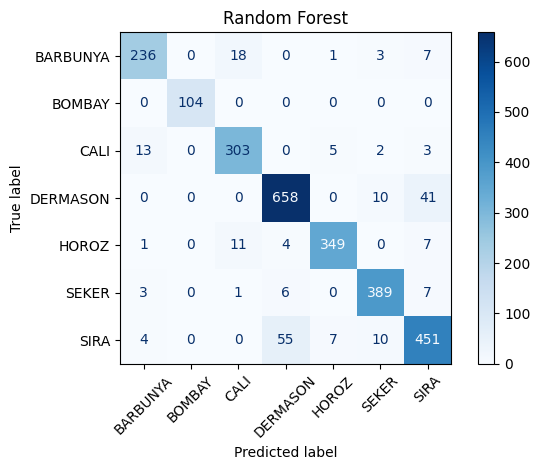

In [16]:
# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

print("\n")
print("="*70)
print("MODEL EVALUATION")
print("="*70)

results = []

classes = np.unique(y_train)

y_test_bin = label_binarize(y_test, classes=classes)

for model_name, model in trained_models.items():

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)

        auc = roc_auc_score(
            y_test_bin,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    else:
        auc = np.nan

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=encoder.classes_
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        xticks_rotation=45,
        cmap="Blues"
    )

    plt.title(model_name)

    plt.tight_layout()

    plt.show()

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc,
        "ROC-AUC": auc
    })






RANDOM FOREST FEATURE IMPORTANCE
            Feature  Importance
1         Perimeter    0.100010
14     ShapeFactor3    0.095227
12     ShapeFactor1    0.095006
11      Compactness    0.085203
3   MinorAxisLength    0.074756
6        ConvexArea    0.072622
5      Eccentricity    0.069052
2   MajorAxisLength    0.068913
4      AspectRation    0.063727
7     EquivDiameter    0.060937
10        roundness    0.058334
0              Area    0.053321
13     ShapeFactor2    0.044237
15     ShapeFactor4    0.029448
9          Solidity    0.018533
8            Extent    0.010674


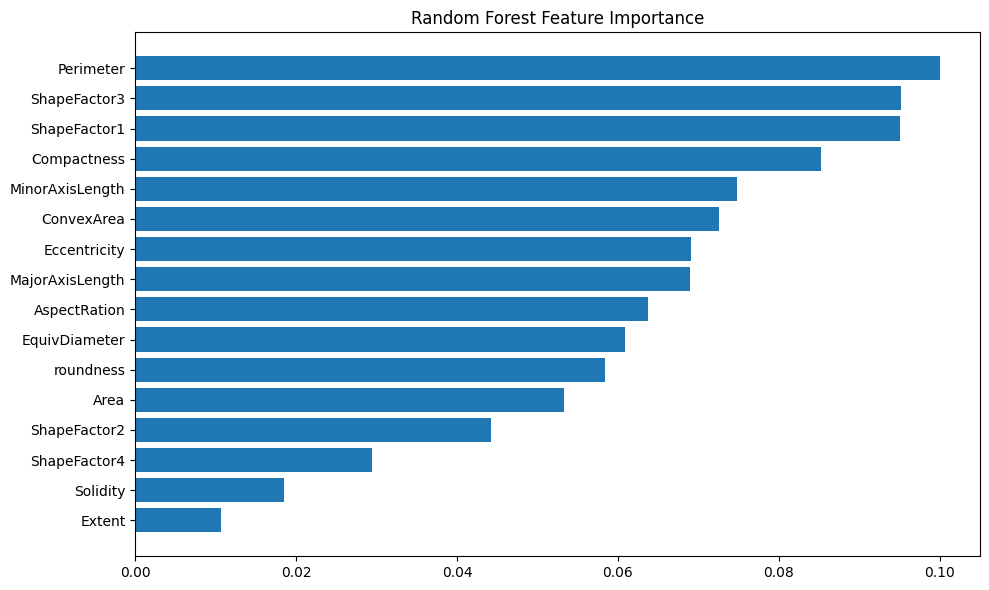

In [17]:
# ==========================================================
# Feature Importance
# ==========================================================

print("\n")
print("="*70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*70)

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",

    ascending=False

)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [18]:

# ==========================================================
# Comparison Table
# ==========================================================

results_df = pd.DataFrame(results)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

results_df.to_csv(
    "output/model_comparison.csv",
    index=False
)

# ==========================================================
# Best Model
# ==========================================================

best_model = results_df.iloc[0]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(f"\nBest Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")
print("\nOverall Winner:", best_model["Model"])

# ==========================================================
# Summary
# ==========================================================

print("\n")
print("="*70)
print("FILES GENERATED")
print("="*70)

print("output/train_processed.csv")
print("output/test_data.csv")
print("output/model_comparison.csv")

print()

print("model/logistic_regression.pkl")
print("model/decision_tree.pkl")
print("model/knn.pkl")
print("model/naive_bayes.pkl")
print("model/random_forest.pkl")
print("model/scaler.pkl")
print("model/label_encoder.pkl")

print("\n")
print("="*70)
print("Dry Bean Model Training Completed Successfully")
print("="*70)



MODEL COMPARISON
   Rank                Model  Accuracy  Precision    Recall  F1 Score  \
0     1  Logistic Regression  0.921004   0.921675  0.921004  0.921173   
1     2        Random Forest  0.919158   0.919149  0.919158  0.919041   
2     3                  KNN  0.913621   0.914400  0.913621  0.913803   
3     4        Decision Tree  0.904024   0.904315  0.904024  0.904014   
4     5          Naive Bayes  0.897010   0.899653  0.897010  0.897199   

        MCC   ROC-AUC  
0  0.904529  0.993599  
1  0.902208  0.991533  
2  0.895555  0.983471  
3  0.883947  0.968871  
4  0.876171  0.989880  


BEST MODEL

Best Model : Logistic Regression
Accuracy   : 0.9210
F1 Score   : 0.9212

Overall Winner: Logistic Regression


FILES GENERATED
output/train_processed.csv
output/test_data.csv
output/model_comparison.csv

model/logistic_regression.pkl
model/decision_tree.pkl
model/knn.pkl
model/naive_bayes.pkl
model/random_forest.pkl
model/scaler.pkl
model/label_encoder.pkl


Dry Bean Model Trainin

In [19]:
print("="*60)

print("Training Completed Successfully")

print("="*60)

print("Models Saved")

print("- Logistic Regression")

print("- Decision Tree")

print("- KNN")

print("- Naive Bayes")

print("- Random Forest")

print("\nFiles Generated")

print("- model_comparison.csv")

print("- All .pkl models")

Training Completed Successfully
Models Saved
- Logistic Regression
- Decision Tree
- KNN
- Naive Bayes
- Random Forest

Files Generated
- model_comparison.csv
- All .pkl models


In [20]:
end = time.time()

print(f"Execution Time : {end-start:.2f} seconds")

Execution Time : 239.30 seconds
